In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nets as nets

El sistema es

$$x_k = x_{k-1} + u_{k-1}$$

con $$u_k = - k\,x_k$$
y $$r = -x^2$$

In [2]:
def sistema(x, k):
  u = -k*x
  y = x + u
  r = -x**2
  return y, r

Se hace temporal difference a un paso, se tiene una red target y otra que se actualiza en cada iteración.

$$V(s) = NN(s) \qquad V_{target}(s) = r(s) + \gamma\,NN_{target}(s)$$

En cada iteracón se actualiza $V$ con la loss

$$L(s) = (V - V_{target})^2$$

y cada 100 iteraciones

$$NN_{target} \leftarrow NN$$



In [3]:
net = nets.ValueNet(1, 32, 1)
import copy
target_net = copy.deepcopy(net)

gamma = 0.9

for episode in range(9000):
    x = np.random.uniform(-5, 5)

    x_next, r = sistema(x, 0.3)
    x = x/5                 #Normalización para no saturar la activacion
    x_next = x_next/5
    v = net.forward(np.array([x]))[0,0]
    y = r + gamma * target_net.forward(np.array([x_next]))[0,0]

    net.backward(y)
    net.update_weights(0.01)

    if episode % 100 == 0:
      target_net = copy.deepcopy(net)

    if episode % 500 == 0:
        print(f"ep {episode}, V(x)={v:.2f}, target={y:.2f}")

ep 0, V(x)=-0.18, target=-0.23
ep 500, V(x)=-43.90, target=-35.06
ep 1000, V(x)=-7.90, target=-6.71
ep 1500, V(x)=-5.96, target=-6.00
ep 2000, V(x)=-12.94, target=-13.43
ep 2500, V(x)=-5.08, target=-4.76
ep 3000, V(x)=-12.22, target=-14.42
ep 3500, V(x)=-6.74, target=-6.31
ep 4000, V(x)=-15.35, target=-15.08
ep 4500, V(x)=-39.85, target=-39.26
ep 5000, V(x)=-12.33, target=-12.22
ep 5500, V(x)=-3.83, target=-3.64
ep 6000, V(x)=-44.23, target=-44.57
ep 6500, V(x)=-5.78, target=-5.78
ep 7000, V(x)=-2.15, target=-2.14
ep 7500, V(x)=-13.54, target=-13.27
ep 8000, V(x)=-10.46, target=-10.41
ep 8500, V(x)=-3.65, target=-3.86


Bellman error medio: 0.2482297889914517


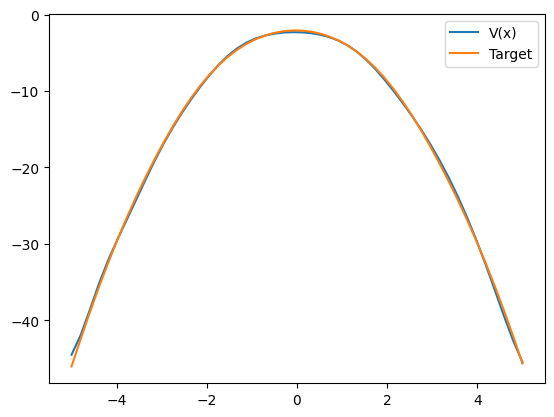

In [4]:
xs = np.linspace(-5,5,50)
errs = []
vs = []
ys = []

for x in xs:
    x_next, r = sistema(x, 0.3)
    x = x/5
    x_next = x_next/5
    v  = net.forward(np.array([x]))[0,0]
    y = r + gamma * net.forward(np.array([x_next]))[0,0]
    err = v - y
    errs.append(err)
    vs.append(v)
    ys.append(y)

print("Bellman error medio:", np.mean(np.abs(errs)))

plt.plot(xs, vs)
plt.plot(xs, ys)
plt.legend(["V(x)", "Target"])
plt.show()